MODELO DE INVERSIÓN. 

PARTE I: ESTRUCTURA INICIAL.

Librerías

In [1]:
import pypsa #PyPSA: Python for Power System Analysis
import pandas as pd #Pandas: Biblioteca para manipulación y análisis de datos
import numpy as np #Numpy: Biblioteca para cálculos numéricos
import matplotlib.pyplot as plt #Matplotlib: Biblioteca para creación de gráficos
import matplotlib.dates as mdates #Matplotlib.dates: Módulo para manejar fechas en gráficos

pypsa.options.api.new_components_api = True # Activar la nueva API de componentes de PyPSA

Creación de Snapshot

In [2]:
# (1) Definir el periodo. 
hours=pd.date_range("2025-01-01", periods=24*7, freq="h") # Una semana de 2025 con resolución horaria

# (2) Crear la red vacía con esos snapshots
network=pypsa.Network()
network.set_snapshots(hours)

# (3) Calcular el peso de cada hora para extrapolar a un año completo
hours_per_year=365*24
snapshot_weight=len(hours)
single_weight=hours_per_year/snapshot_weight

#(4) Asignar el peso a cada snapshot
network.snapshot_weightings= pd.Series(single_weight,  index=network.snapshots)

INFO:pypsa.network.index:Applying weightings to all columns of `snapshot_weightings`


Lectura de Hojas de Datos (excel integrado)

In [3]:
# Lectura de datos desde archivo Excel integrado
data = pd.read_excel(
    r"C:\Users\EXT10348\Downloads\WinPython 3.12.10\WPy64-31241\PROYECTOS PYPSA\hojas_de_datos\modelo_dispatching_españa_portugal.xlsx",
    sheet_name=None,
    engine="openpyxl"
)

In [4]:
# Verificación de correcta lectura de datos
print(data.keys())  # Muestra las hojas disponibles en el archivo Excel

dict_keys(['Guide Sheet', 'buses', 'carriers', 'generators', 'links', 'loads', 'storage_units', 'store', 'snaptshots', 'profiles', 'demands', 'Hoja11'])


In [13]:

n = pypsa.Network()
n.import_from_excel(
    r"C:\Users\EXT10348\Downloads\WinPython 3.12.10\WPy64-31241\PROYECTOS PYPSA\hojas_de_datos\modelo_dispatching_españa_portugal.xlsx",
    engine="openpyxl"
)


INFO:pypsa.network.io:New version 1.0.4 available! (Current: 1.0.2)
Index(['CCGT', 'turbina ', 'pump', 'electrolyzer'], dtype='object', name='name')
Index(['CCGT', 'turbina ', 'pump', 'electrolyzer'], dtype='object', name='name')
Index(['demand', 'hydrogen_demand'], dtype='object', name='name')
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, links, loads, storage_units


In [12]:
n.buses

'Bus' Components
----------------
Attached to PyPSA Network 'Unnamed Network'
Components: 4

In [16]:

file = "C:\\Users\\EXT10348\\Downloads\\WinPython 3.12.10\\WPy64-31241\\PROYECTOS PYPSA\\hojas_de_datos\\modelo_dispatching_españa_portugal.xlsx" # Ruta al archivo Excel
hours_week = 168 # flexible para definir semanas
hours_year = 8760 # flexible para definir años

#________________Perfiles de generación renovable _____________________________________________________________________________________________________________________________________________

df_profiles = pd.read_excel(file, sheet_name="profiles") # Leer la hoja 'profiles' del archivo Excel
df_profiles["date"] = pd.to_datetime(df_profiles["date"]) # Asegurar que la columna de fecha es datetime

solar_profile_ES     = df_profiles["solar_profile_ES"].iloc[:hours_year].reset_index(drop=True) # lee columna solar_profile_zaragoza
wind_profile_ES      = df_profiles["wind_profile_ES"].iloc[:hours_year].reset_index(drop=True) # lee columna wind_profile_zaragoza
hydraulic_profile = df_profiles["hydraulic_profile"].iloc[:hours_week].reset_index(drop=True) # lee columna hydraulic_profile

# _______________ Demandas 2040  ______________________________________________________________________________________________________________________________________________________________

df_demand2040 = pd.read_excel(file, sheet_name="demands") 
df_profiles["date"] = pd.to_datetime(df_profiles["date"]) 

demand_2040_españa = df_demand2040["demand_2040"].iloc[:hours_week].reset_index(drop=True)
hydrogen_demand = df_demand2040["hydrogen_demand"].iloc[:hours_week].reset_index(drop=True)





C:\Users\EXT10348\AppData\Local\Temp\ipykernel_26420\1854556073.py:4: FutureWarning:

'H' is deprecated and will be removed in a future version, please use 'h' instead.



ValueError: x and y must have same first dimension, but have shapes (168,) and (8760,)

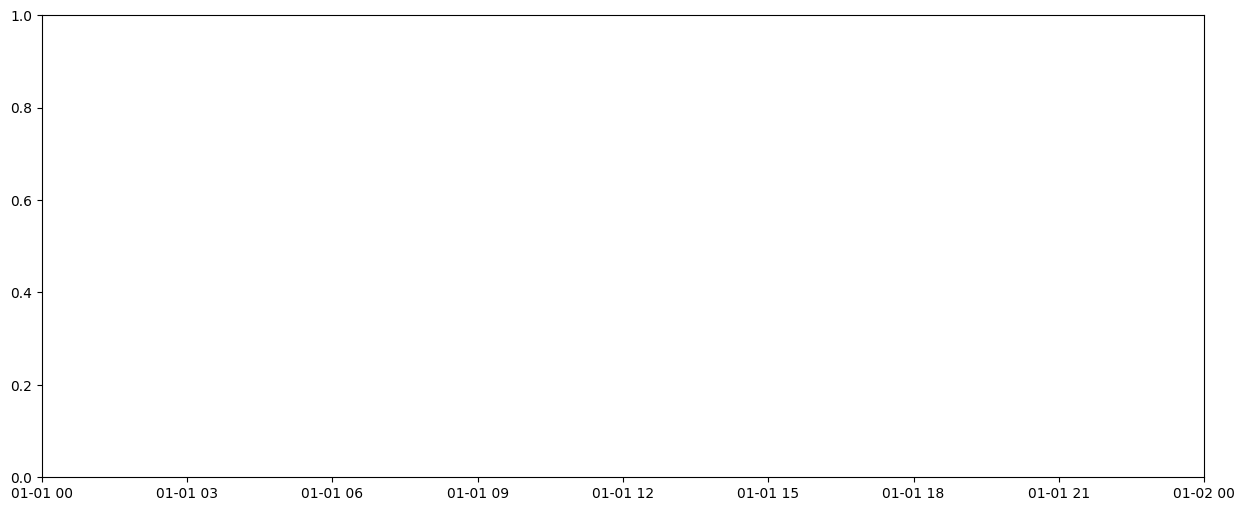

In [19]:
# GRAFICAR

# Gráfica de Perfiles Horarios de Generación Renovable.
hours = pd.date_range(start="2025-01-01", end="2025-01-07 23:00", freq="H") #para que no me ploteé el día 8 con 1 hora
plt.figure(figsize=(15, 6))
plt.style.use('default')
plt.plot(hours, solar_profile_ES, label="E. Solar", color="orange", linewidth=1, linestyle="-")
plt.plot(hours, wind_profile_ES, label="E. Eólica", color="skyblue", linewidth=1, linestyle="-")
plt.title("Perfiles horarios de generación renovable", fontsize=14, fontweight="bold")
plt.xlabel("Hora", fontsize=12)
plt.ylabel("Electricidad (p.u.)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=12)
plt.tight_layout()
plt.fill_between(hours, solar_profile_ES, color="orange", alpha=0.2)
plt.fill_between(hours, wind_profile_ES, color="skyblue", alpha=0.2)

for day in pd.date_range("2025-01-01", "2025-01-07"):
    for hour in [0, 6, 12, 18]:
        timestamp = pd.Timestamp(day.date()) + pd.Timedelta(hours=hour)
        plt.axvline(x=timestamp, color='black', linestyle=':', linewidth=0.5, alpha=0.4)
       
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y: %H'))
plt.xticks(rotation=45)
plt.show()



C:\Users\EXT10348\AppData\Local\Temp\ipykernel_8584\1501829233.py:2: FutureWarning:

'H' is deprecated and will be removed in a future version, please use 'h' instead.



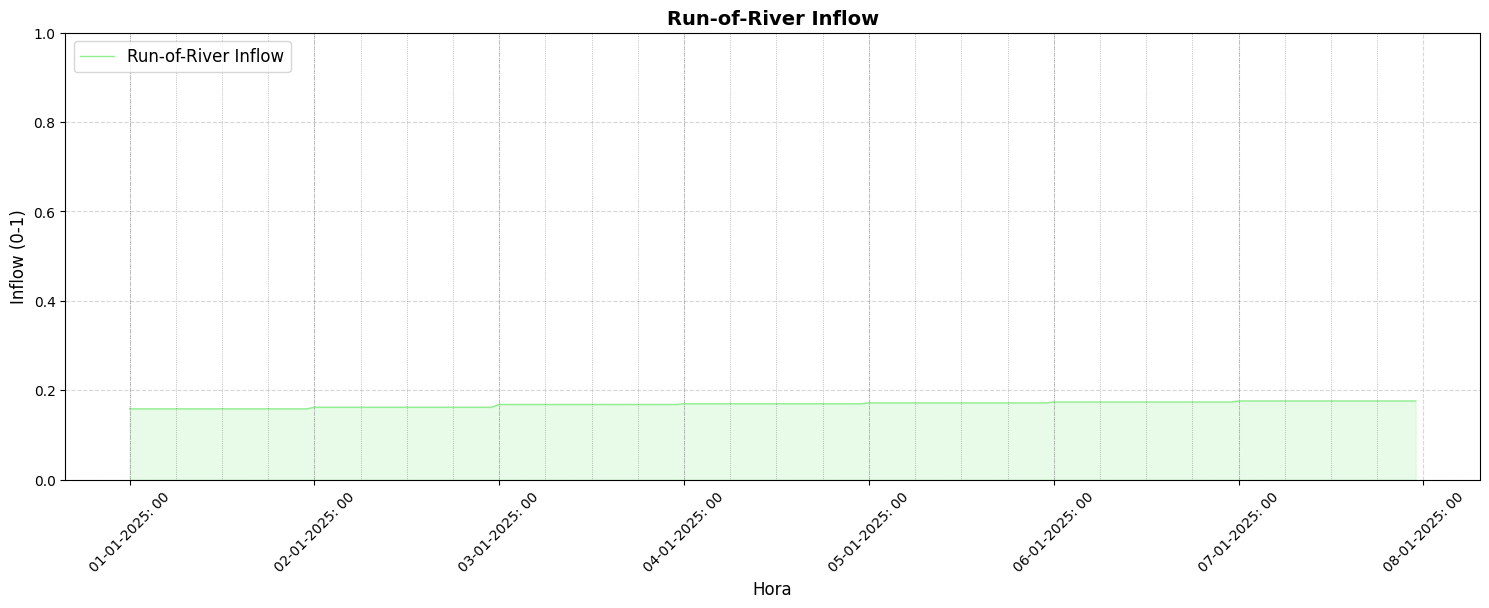

In [105]:

#Gráfica Inflow Run-of-River
hours = pd.date_range(start="2025-01-01", end="2025-01-07 23:00", freq="H") #para que no me ploteé el día 8 con 1 hora

plt.figure(figsize=(15, 6))
plt.style.use('default')
plt.plot(hours, hydro_inflows, label="Run-of-River Inflow", color="lightgreen", linewidth=1, linestyle="-")
plt.fill_between(hours, hydro_inflows, color="lightgreen", alpha=0.2)
plt.title("Run-of-River Inflow", fontsize=14, fontweight="bold")
plt.xlabel("Hora", fontsize=12)
plt.ylabel("Inflow (0-1)", fontsize=12)
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=12)
plt.tight_layout()

for day in pd.date_range("2025-01-01", "2025-01-07"):
    for hour in [0, 6, 12, 18]:
        timestamp = pd.Timestamp(day.date()) + pd.Timedelta(hours=hour)
        plt.axvline(x=timestamp, color='black', linestyle=':', linewidth=0.5, alpha=0.4)
       
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y: %H'))
plt.xticks(rotation=45)
plt.show()





C:\Users\EXT10348\AppData\Local\Temp\ipykernel_8584\3255236423.py:3: FutureWarning:

'H' is deprecated and will be removed in a future version, please use 'h' instead.



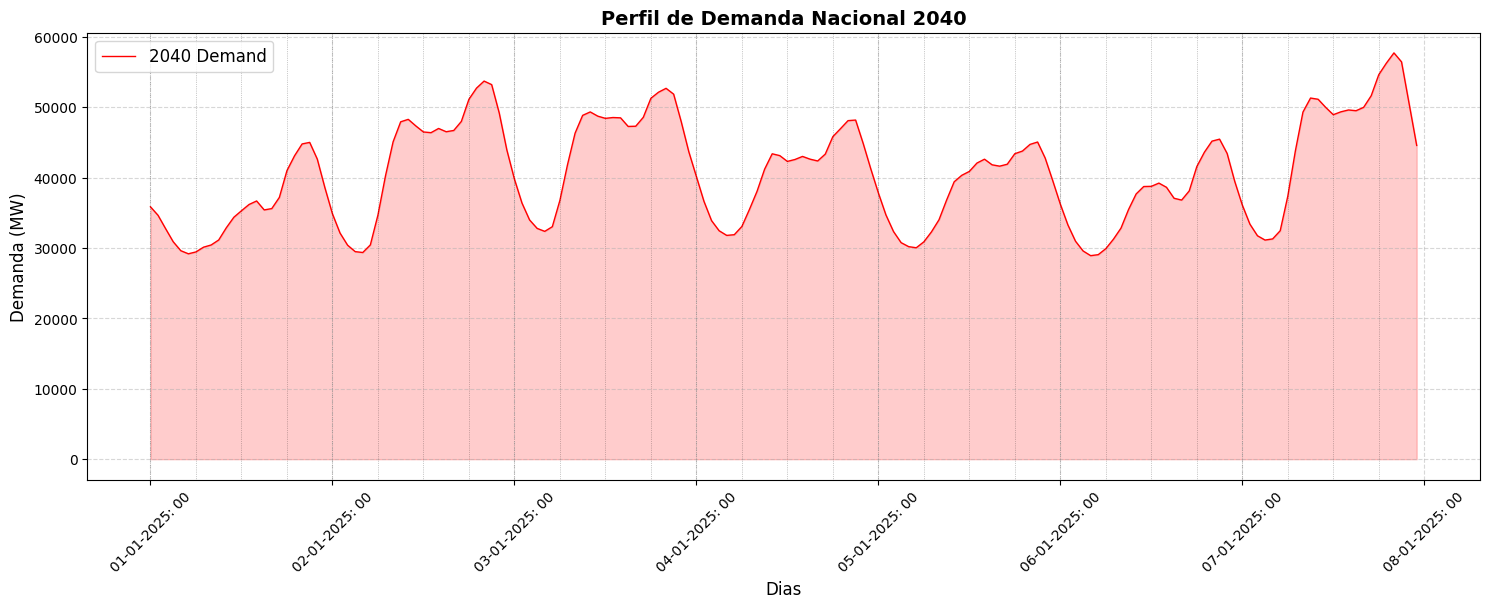

In [106]:
 
# Dibuja la Demanda para la primera semana de 2040.

hours = pd.date_range(start="2025-01-01", end="2025-01-07 23:00", freq="H") #para que no me ploteé el día 8 con 1 hora
plt.figure(figsize=(15, 6))
plt.style.use('default')
plt.plot(hours, demand_profile, label="2040 Demand", color="red", linewidth=1, linestyle="-")
plt.fill_between(hours, demand_profile, color="red", alpha=0.2)
plt.title("Perfil de Demanda Nacional 2040",  fontsize=14, fontweight="bold")
plt.xlabel("Dias", fontsize=12)
plt.ylabel("Demanda (MW)", fontsize=12)

plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=12)
plt.tight_layout()

for day in pd.date_range("2025-01-01", "2025-01-07"):
    for hour in [0, 6, 12, 18]:
        timestamp = pd.Timestamp(day.date()) + pd.Timedelta(hours=hour)
        plt.axvline(x=timestamp, color='black', linestyle=':', linewidth=0.5, alpha=0.4)
       
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y: %H'))
plt.xticks(rotation=45)
plt.show()

PARTE II: CREACIÓN DEL ENTORNO: Llamada a Componentes

In [107]:
# Carriers
df_carriers = data["Carriers"]

for _, carrier in df_carriers.iterrows():
    network.add(
        "Carrier", 
        carrier["Name"],           
        overwrite=carrier["Overwrite"]
    )

In [108]:
# Buses
df_buses=data["Buses"]
for _, bus in df_buses.iterrows():
    network.add(
        "Bus", 
        bus["Name"], 
        carrier=bus["carrier"], 
        overwrite=bus["overwrite"]
    )

In [109]:
# GENERADORES
# ---------------------------------------------------------------------------------------------------------------------
# -------------- Te indica de que hoja vamos a asignar los datos ------------------------------------------------------
df_generators=data["Generators"]
# ---------------- Se asegura de que el índice de solar y wind coincidan ----------------------------------------------
solar_profile.index = hours
wind_profile.index  = hours
# ---------------- Asignas los atributos de los generadores -----------------------------------------------------------
for _, gen in df_generators.iterrows():
    carrier_key = gen["carrier"].strip().lower()
    gen_kwargs = {      
        "bus":           gen["Bus"],
        "p_nom":         gen["p_nom"],
        "marginal_cost": gen["marginal_cost"],
        "carrier":       gen["carrier"],
        "overwrite":     gen["overwrite"]
    }
# ---------------- Asignas el perfil horario cuando el generador es solar, wind o water -------------------------------
    if carrier_key == "solar":
        gen_kwargs["p_max_pu"] = solar_profile
    elif carrier_key == "wind":
        gen_kwargs["p_max_pu"] = wind_profile
    elif carrier_key == "Water":
        gen_kwargs["p_max_pu"] = hydro_inflows
# ---------------- Añades el generador a tu modelo ---------------------------------------------------------------------
    network.add("Generator", gen["Name"], **gen_kwargs)
# ---------------------------------------------------------------------------------------------------------------------

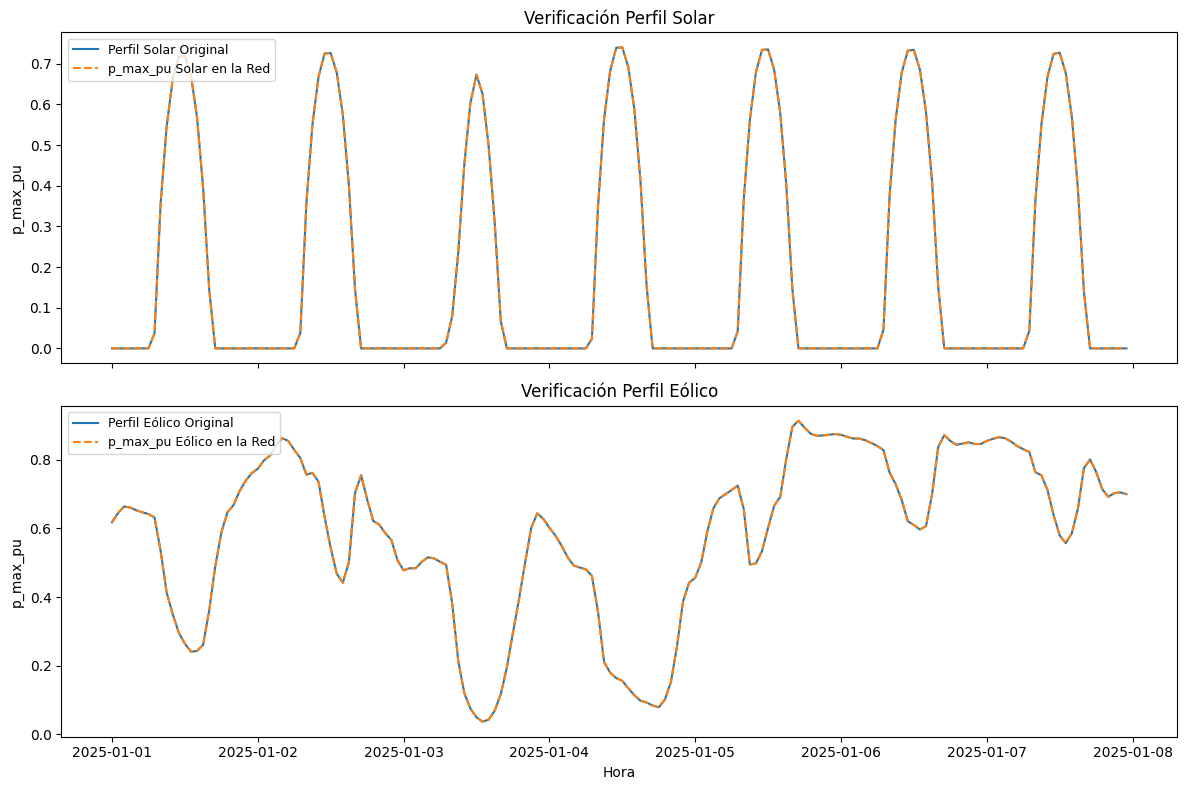

In [110]:
#VERIFICACIÓN DEL PERFIL SOLAR

# Extrae las series de p_max_pu desde la red
solar_pm = network.generators_t.p_max_pu["Solar"]
wind_pm  = network.generators_t.p_max_pu["Wind"]

# Crea la figura con dos subplots
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Plot Solar
axes[0].plot(solar_profile.index, solar_profile, label="Perfil Solar Original")
axes[0].plot(solar_pm.index,     solar_pm,     linestyle="--", label="p_max_pu Solar en la Red")
axes[0].set_title("Verificación Perfil Solar")
axes[0].set_ylabel("p_max_pu")
axes[0].legend(loc="upper left", fontsize=9)

# Plot Wind
axes[1].plot(wind_profile.index, wind_profile, label="Perfil Eólico Original")
axes[1].plot(wind_pm.index,      wind_pm,      linestyle="--", label="p_max_pu Eólico en la Red")
axes[1].set_title("Verificación Perfil Eólico")
axes[1].set_xlabel("Hora")
axes[1].set_ylabel("p_max_pu")
axes[1].legend(loc="upper left", fontsize=9)

plt.tight_layout()
plt.show()

In [111]:
# Loads

h2_profile = pd.Series(8652.968037, index=network.snapshots)

df_loads = data["Loads"]
for _, loads in df_loads.iterrows():
    network.add(
        "Load", 
        loads["Name"], 
        bus=loads["Bus"], 
        p_set=h2_profile, 
        carrier=bus["carrier"],
        overwrite=loads["overwrite"]
         )
    
network.add(
        "Load",
        name="Demanda_Nacional", #tiene un único nombre.
        bus="electricity_Market",
        p_set=df_demand['DEMANDA REAL 2040'], #Es una serie temporal (time series) con la potencia demandada (en MW ) para cada instante de tiempo (cada hora de la primera semana del año 2040).
        carrier="Electricity",
        overwrite=True
        )

demand = network.loads_t.p_set["Demanda_Nacional"]


In [112]:
# Links
# ---------------------------------------------------------------------------------------------
# -------------- Te indica de que hoja vamos a asignar los datos ------------------------------
df_links = data["Links"]
# ---------------- Check if buses exist -------------------------------------------------------
for _, lk in df_links.iterrows():
    name = lk["Name"].strip()
    bus0 = lk["Bus 1"].strip()
    bus1 = lk["Bus 2"].strip()


    if bus0 not in network.buses.index:
        raise ValueError(f"Bus '{bus0}' not found in network")
    if bus1 not in network.buses.index:
        raise ValueError(f"Bus '{bus1}' not found in network")

# --------------- se recorren las celdas, y se crean los links ---------------------------------
for _, lk in df_links.iterrows():
    name      = lk["Name"].strip()
    bus0      = lk["Bus 1"]
    bus1      = lk["Bus 2"]
    p_nom     = lk["p_nom"]
    capital_cost = lk["capital_cost"]
    eff       = lk["efficiency"]
    mcost     = lk["marginal_cost"]
    carrier   = lk["carrier"]
    overwrite = lk["overwrite"]

# -------------- Dependiendo de la tecnología del link, ajustamos parámetros --------------------
# -------------- CCGT  -------------------------------------------------------------------------
    if name.lower() == "ccgt":
        network.add(
            "Link", name,
            bus0=bus0, bus1=bus1,
            p_nom=p_nom, efficiency=eff,
            marginal_cost=mcost, carrier=carrier,
            capital_cost=capital_cost,
            overwrite=overwrite,
            #ramp_limit_up=lk["Ramp limit up"],
            #ramp_limit_down=lk["Ramp limit down"]
        )
# -------------- Turbina hidroeléctrica  -----------------------------------------------------------
    elif name.lower() == "turbina":
        network.add(
            "Link", name,
            bus0=bus0, bus1=bus1,
            p_nom=p_nom, efficiency=eff,
            marginal_cost=mcost, carrier=carrier,#p_nom_extendable=p_nom_extendable, 
            capital_cost=capital_cost,
            overwrite=overwrite
        )
# -------------- Bomba  --------------------------------------------------------------------------
    elif name.lower() == "pump":
        network.add(
            "Link", name,
            bus0=bus0, bus1=bus1,
            p_nom=p_nom, efficiency=eff,
            marginal_cost=mcost, carrier=carrier,
            overwrite=overwrite
        )
# -------------- electrolyzer ---------------------------------------------------------------------
    elif name.lower() == "electrolyzer":
        network.add(
            "Link", name,
            bus0=bus0, bus1=bus1,
            p_nom=p_nom, efficiency=eff,
            marginal_cost=mcost, carrier=carrier,
            overwrite=overwrite
        )

In [113]:
# Verificación
     
print("\n=== Resumen de todos los Links en la red ===")
print(network.links[[
        'bus0','bus1','p_nom','efficiency','marginal_cost','carrier',
        'ramp_limit_up','ramp_limit_down'
    ]])
for link_name in ["CCGT", "Turbina", "Pump", "Electrolyzer"]:
        if link_name in network.links.index:
            row = network.links.loc[link_name]
            print(f"\n--- Detalle de {link_name} ---")
            print(f"Origen (bus0):        {row['bus0']}")
            print(f"Destino (bus1):       {row['bus1']}")
            print(f"Capacidad (p_nom):    {row['p_nom']} MW")
            print(f"Eficiencia:           {row['efficiency']*100:.1f}%")
            print(f"Coste marginal:       {row['marginal_cost']} €/MWh")
            print(f"Carrier:              {row['carrier']}")
            # Ramp limits solo para CCGT
            #if link_name == "CCGT":
            #    print(f"Ramp up limit:        {row['ramp_limit_up']} MW/h")
            #    print(f"Ramp down limit:      {row['ramp_limit_down']} MW/h")
        #else:
            #print(f"\n⚠️ El link '{link_name}' no se encontró en la red.")


=== Resumen de todos los Links en la red ===
                            bus0                bus1         p_nom  \
name                                                                 
CCGT                     gas_bus  electricity_Market  24559.640000   
Turbina                water_bus  electricity_Market  25140.266473   
Pump          electricity_Market           water_bus  13320.750633   
Electrolyzer  electricity_Market        hydrogen_bus  48100.000000   

              efficiency  marginal_cost   carrier  ramp_limit_up  \
name                                                               
CCGT                0.58           96.0       Gas            NaN   
Turbina             0.85            4.0     Water            NaN   
Pump                0.75           40.0        AC            NaN   
Electrolyzer        0.70            0.0  Hydrogen            NaN   

              ramp_limit_down  
name                           
CCGT                      NaN  
Turbina                   Na

In [114]:
# Storage Units

df_storage = data["StorageUnit"]
for _, st in df_storage.iterrows():
    name      = st["Name"].strip()
    bus      = st["Bus"]         # origen de la energía
    p_nom     = st["p_nom"]         # capacidad nominal
    max_hours = st["max_hours"]         # horas máximas de almacenamiento
    efficiency_store = st["efficiency_store"]  # eficiencia de carga
    efficiency_dispatch = st["efficiency_dispatch"]  # eficiencia de descarga
    marginal_cost = st["marginal_cost"]   # coste marginal
    cyclic_state_of_charge = st["cyclic_state_of_charge"]  # estado de carga cíclico
    state_of_charge_initial=0.5 * st["p_nom"] * st["max_hours"]
    carrier   = st["carrier"]         # etiqueta de carrier
    overwrite = st["overwrite"]       # si sobreescribe parámetros
    # Para CCGT incluimos además ramp limits
    if name.lower() == "hstorage":
        network.add("StorageUnit", 
            name= name, 
            bus=bus, 
            p_nom=p_nom, 
            max_hours=max_hours, 
            efficiency_store=efficiency_store, 
            efficiency_dispatch=efficiency_dispatch,
            marginal_cost=marginal_cost, 
            carrier=carrier, 
            overwrite=overwrite, 
            capital_cost=capital_cost
        )

        print(f"StorageUnit {name} añadida en bus {bus}: {p_nom} MW · {max_hours} h y marginal cost {marginal_cost}")

    elif name.lower() == "battery":
        network.add("StorageUnit",
            name= name, 
            bus=bus, 
            p_nom=p_nom, 
            max_hours = max_hours,
            efficiency_store=efficiency_store, 
            efficiency_dispatch=efficiency_dispatch,
            marginal_cost=marginal_cost, 
            #cyclic_state_of_charge=cyclic_state_of_charge, 
            carrier=carrier, 
            #state_of_charge_initial=0.5 * p_nom * max_hours, 
            overwrite=overwrite, 
            capital_cost=capital_cost
        )
        
        print(f"StorageUnit {name} añadida en bus {bus}: {p_nom} MW · {max_hours} h y marginal cost {marginal_cost}")

StorageUnit Battery añadida en bus electricity_Market: 266985.2 MW · 4 h y marginal cost 0.1
StorageUnit Hstorage añadida en bus hydrogen_bus: 10000.0 MW · 1000 h y marginal cost 2.0


In [115]:
# Store
# --------------------------------------------------------------------------------------------
df_store = data["Store"]
print("Type of df_store:", type(df_store))
for _, store in df_store.iterrows():
    network.add("Store", 
        store["Name"], 
        bus=store["Bus"], 
        e_nom=store["e_nom"],
        e_initial=store["e_initial"], 
        e_min_pu=store["e_min_pu"], 
        e_max_pu=store["e_max_pu"],  
        e_cyclic=store["cyclic_state_of_charge"], 
        capital_cost=store["capital_cost"], 
        marginal_cost=store["marginal_cost"], 
        carrier=store["carrier"],
        overwrite=store["overwrite"]
        )
# ------------- Verificación --------------------------------------------------------------
    print(f"Store: {store['Name']} añadido en bus {store['Bus']}: {store['e_nom']} MWh · inicial {store['e_initial']} MWh · min {store['e_min_pu']} pu · max {store['e_max_pu']} pu · coste marginal {store['marginal_cost']}")

Type of df_store: <class 'pandas.core.frame.DataFrame'>
Store: Embalse añadido en bus water_bus: 1387684000 MWh · inicial 1248915600 MWh · min 0.2 pu · max 0.9 pu · coste marginal 1


In [116]:
# ---------------------- Verificaciones ----------------------------------------------------------------
print("Solar p_max_pu:\n", network.generators_t.p_max_pu["Solar"].head())
print("Wind  p_max_pu:\n", network.generators_t.p_max_pu["Wind"].head())
print("Información de inversión de los generadores:")
print(network.generators)
print(network.links)

Solar p_max_pu:
 snapshot
2025-01-01 00:00:00    0.0
2025-01-01 01:00:00    0.0
2025-01-01 02:00:00    0.0
2025-01-01 03:00:00    0.0
2025-01-01 04:00:00    0.0
Freq: h, Name: Solar, dtype: float64
Wind  p_max_pu:
 snapshot
2025-01-01 00:00:00    0.618
2025-01-01 01:00:00    0.645
2025-01-01 02:00:00    0.664
2025-01-01 03:00:00    0.661
2025-01-01 04:00:00    0.653
Freq: h, Name: Wind, dtype: float64
Información de inversión de los generadores:
                        bus control type         p_nom  p_nom_mod  \
name                                                                
Solar    electricity_Market      PQ       3.103384e+05        0.0   
Wind     electricity_Market      PQ       2.595989e+05        0.0   
Biomass  electricity_Market      PQ       2.462660e+03        0.0   
Gas                 gas_bus      PQ       1.000000e+14        0.0   
Water    electricity_Market      PQ       3.117919e+03        0.0   

         p_nom_extendable  p_nom_min  p_nom_max  p_nom_set  p_min_

RESTRICCIONES

In [117]:
# EMISIONES DE CO2.
# --------------------------- Precio CO2 y factor de emisión --------------------------------
co2_price = 100  # €/tCO2
emission_factor = 0.202  # tCO2/MWh para gas
# --------------------------- Coste adicional por CO2 ----------------------------------------
co2_cost = co2_price * emission_factor  # 20.2 €/MWh
# --------------------------- Sumarlo al coste marginal del link CCGT ------------------------
network.links.at["CCGT", "marginal_cost"] += co2_cost

PARTE III: OPTIMIZACIÓN

In [118]:
network.optimize(solver_name="highs")

Index(['electricity_Market', 'water_bus'], dtype='object', name='name')
Index(['Water '], dtype='object', name='name')
Index(['Demanda_Nacional'], dtype='object', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.12s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 2856 primals, 6552 duals
Objective: 1.38e+08
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Link-fix-p-lower, Link-fix-p-upper, Store-fix-e-lower, Store-fix-e-upper, StorageUnit-fix-p_dispatch-lower, StorageUnit-fix-p_dispatch-upper, StorageUnit-fix-p_store-lower, StorageUnit-fix-p_store-upper, StorageUnit-fix-state_of_charge-lower, StorageUnit-fix-state_of_charge-upper, StorageUnit-energy_balance, Store-energy_balance were not assigned to the network.


('ok', 'optimal')

PARTE IV: OBTENCIÓN DE RESULTADOS.

{'nodes': {'Bus': <matplotlib.collections.PatchCollection at 0x13909c75dc0>},
 'branches': {'Link': <matplotlib.collections.LineCollection at 0x13909c742f0>},
 'flows': {}}

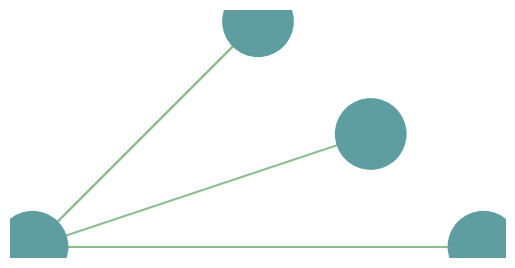

In [119]:
network.plot()

In [120]:
# RESULTADOS NUMÉRICOS QUE CUBREN LA DEMANDA
print(" Generator p:", network.generators_t.p.iloc[0])
print("Link p0:",     network.links_t.p0.iloc[0])
print("Link p1:",     network.links_t.p1.iloc[0])
print(" Load p:",      network.loads_t.p_set.iloc[0])

 Generator p: name
Solar         -0.000000
Wind       48207.337623
Biomass       -0.000000
Gas           -0.000000
Water         -0.000000
Name: 2025-01-01 00:00:00, dtype: float64
Link p0: name
CCGT               -0.00000
Turbina            -0.00000
Pump               -0.00000
Electrolyzer    12361.38291
Name: 2025-01-01 00:00:00, dtype: float64
Link p1: name
CCGT               0.000000
Turbina            0.000000
Pump               0.000000
Electrolyzer   -8652.968037
Name: 2025-01-01 00:00:00, dtype: float64
 Load p: name
Demand               8652.968037
Demanda_Nacional    35845.954713
Name: 2025-01-01 00:00:00, dtype: float64


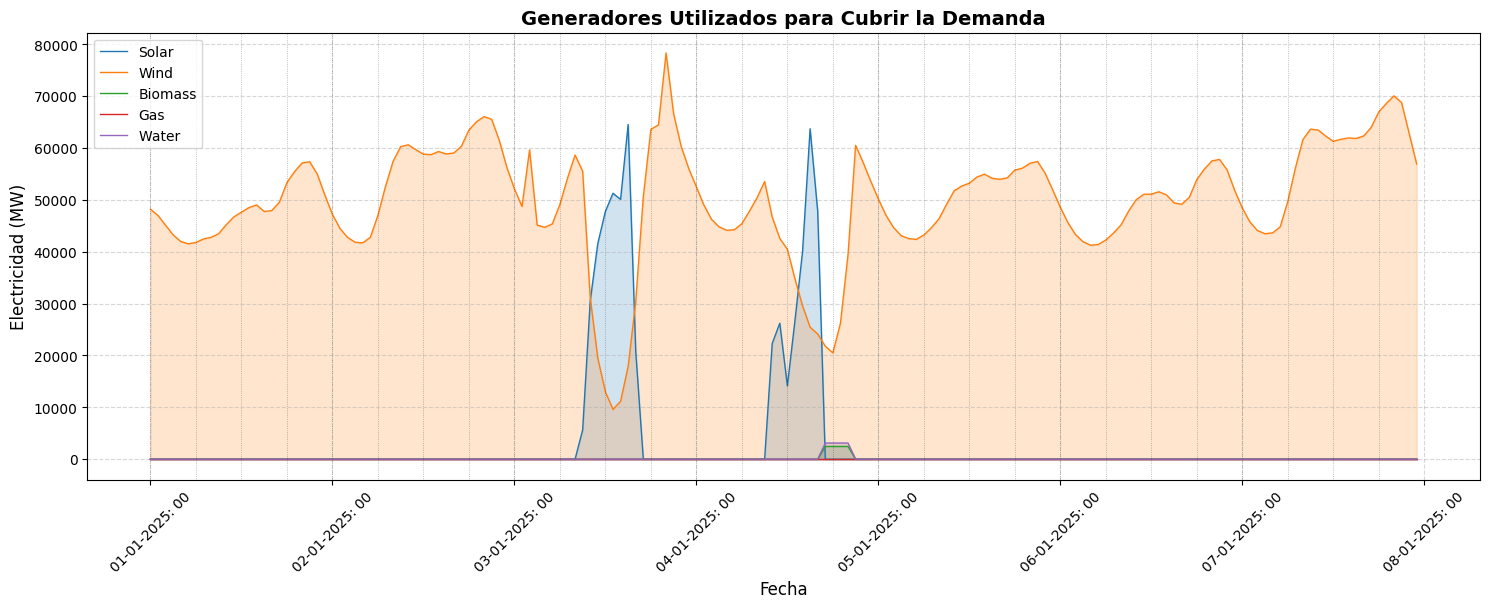

In [121]:
# Gráfica de Generadores Utilizados para Cubrir la Demanda
# ----------------------------------------------------------------------------------------------------------------------------------------
hours = pd.date_range(start="2025-01-01", end="2025-01-07 23:00", freq="h") 
plt.figure(figsize=(15, 6))
plt.style.use('default')
# -------------------- Graficar cada generador manualmente ------------------------------------------------------------------------------
for gen in network.generators_t.p.columns:
    y= network.generators_t.p[gen]
    plt.plot(hours, network.generators_t.p[gen], label=gen, linewidth=1)
    plt.fill_between(hours, y, color=plt.gca().lines[-1].get_color(), alpha=0.2)
# -------------------- Personalización --------------------------------------------------------------------------------------------------
plt.title("Generadores Utilizados para Cubrir la Demanda", fontsize=14, fontweight="bold")
plt.xlabel("Fecha", fontsize=12)
plt.ylabel("Electricidad (MW)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=10)
plt.tight_layout()
# --------------------- Líneas verticales -----------------------------------------------------------------------------------------------
for day in pd.date_range("2025-01-01", "2025-01-07"):
    for hour in [0, 6, 12, 18]:
        timestamp = pd.Timestamp(day.date()) + pd.Timedelta(hours=hour)
        plt.axvline(x=timestamp, color='black', linestyle=':', linewidth=0.5, alpha=0.4)
# --------------------- Formato del eje X ------------------------------------------------------------------------------------------------
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y: %H'))
# ----------------------------------------------------------------------------------------------------------------------------------------
plt.show()
# ----------------------------------------------------------------------------------------------------------------------------------------

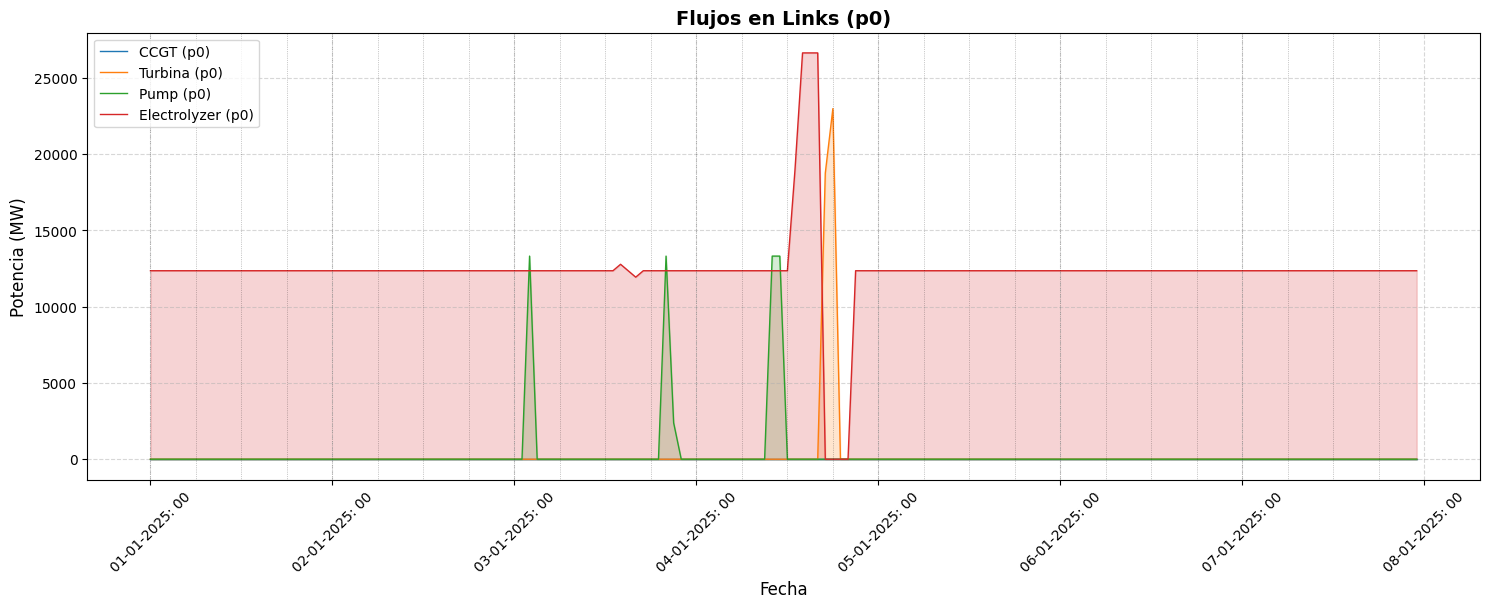

In [122]:
# Flujos en Links
hours = pd.date_range(start="2025-01-01", end="2025-01-07 23:00", freq="h")

plt.figure(figsize=(15, 6))
plt.style.use('default')

# Graficar cada link manualmente (p0)
for link in network.links_t.p0.columns:
    y = network.links_t.p0[link]
    plt.plot(hours, y, label=f"{link} (p0)", linewidth=1)
    plt.fill_between(hours, y, color=plt.gca().lines[-1].get_color(), alpha=0.2)

# Personalización
plt.title("Flujos en Links (p0)", fontsize=14, fontweight="bold")
plt.xlabel("Fecha", fontsize=12)
plt.ylabel("Potencia (MW)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=10)
plt.tight_layout()

# Líneas verticales
for day in pd.date_range("2025-01-01", "2025-01-07"):
    for hour in [0, 6, 12, 18]:
        timestamp = pd.Timestamp(day.date()) + pd.Timedelta(hours=hour)
        plt.axvline(x=timestamp, color='black', linestyle=':', linewidth=0.5, alpha=0.4)
# Formato del eje X
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y: %H'))
plt.show()


C:\Users\EXT10348\AppData\Local\Temp\ipykernel_8584\3558469089.py:2: FutureWarning:

'H' is deprecated and will be removed in a future version, please use 'h' instead.



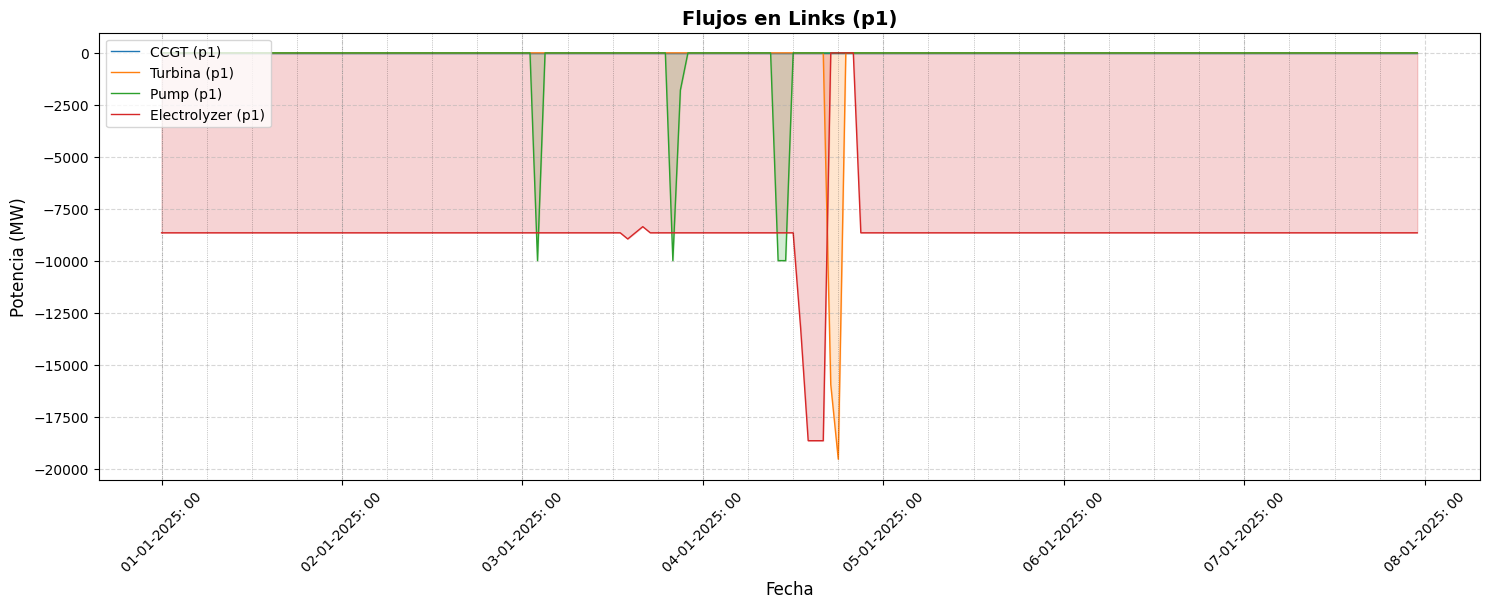

In [123]:

# Asegurar las horas correctas
hours = pd.date_range(start="2025-01-01", end="2025-01-07 23:00", freq="H")

plt.figure(figsize=(15, 6))
plt.style.use('default')

# Graficar cada link manualmente (p1)
for link in network.links_t.p1.columns:
    y = network.links_t.p1[link]
    plt.plot(hours, y, label=f"{link} (p1)", linewidth=1)
    plt.fill_between(hours, y, color=plt.gca().lines[-1].get_color(), alpha=0.2)

# Personalización
plt.title("Flujos en Links (p1)", fontsize=14, fontweight="bold")
plt.xlabel("Fecha", fontsize=12)
plt.ylabel("Potencia (MW)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=10)
plt.tight_layout()

# Líneas verticales
for day in pd.date_range("2025-01-01", "2025-01-07"):
    for hour in [0, 6, 12, 18]:
        timestamp = pd.Timestamp(day.date()) + pd.Timedelta(hours=hour)
        plt.axvline(x=timestamp, color='black', linestyle=':', linewidth=0.5, alpha=0.4)

# Formato del eje X
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y: %H'))
plt.show()

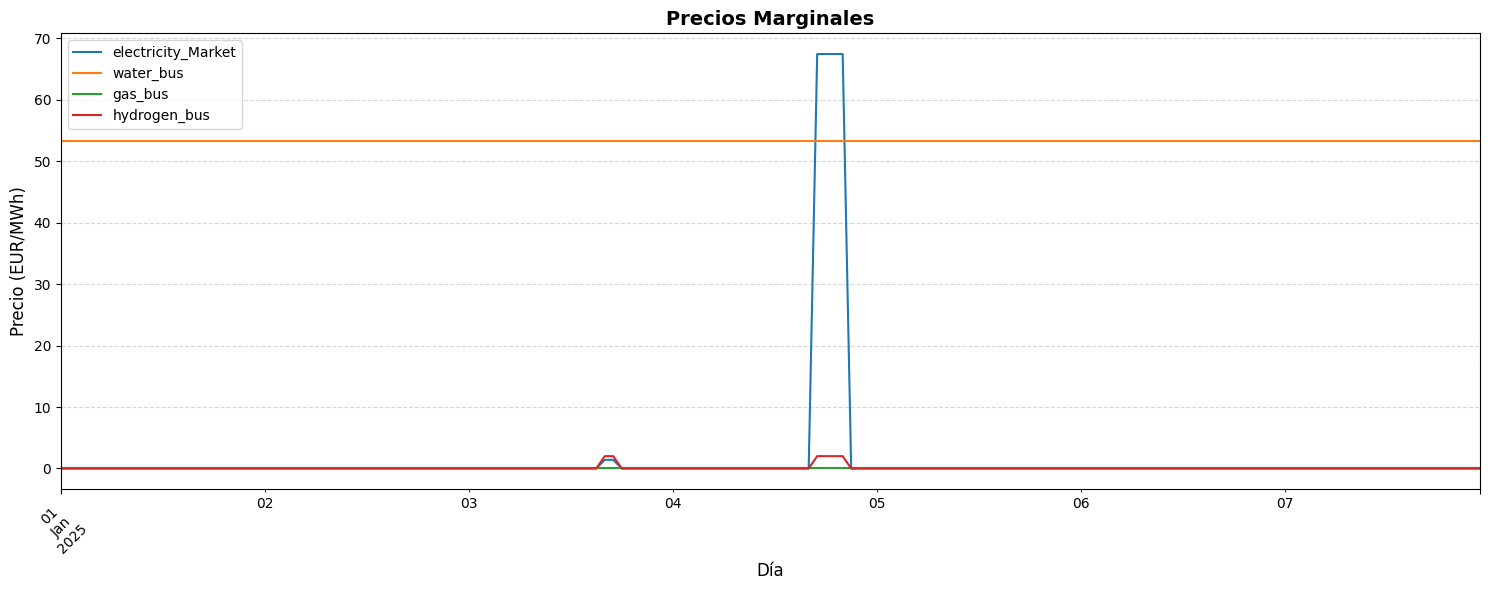

In [124]:
# PRECIOS MARGINALES
network.buses_t.marginal_price.plot(figsize=(15, 6), title="Precios Marginales")

# Personalización
plt.title("Precios Marginales", fontsize=14, fontweight="bold")
plt.xlabel("Día", fontsize=12)
plt.ylabel("Precio (EUR/MWh)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=10)
plt.tight_layout()
plt.show()

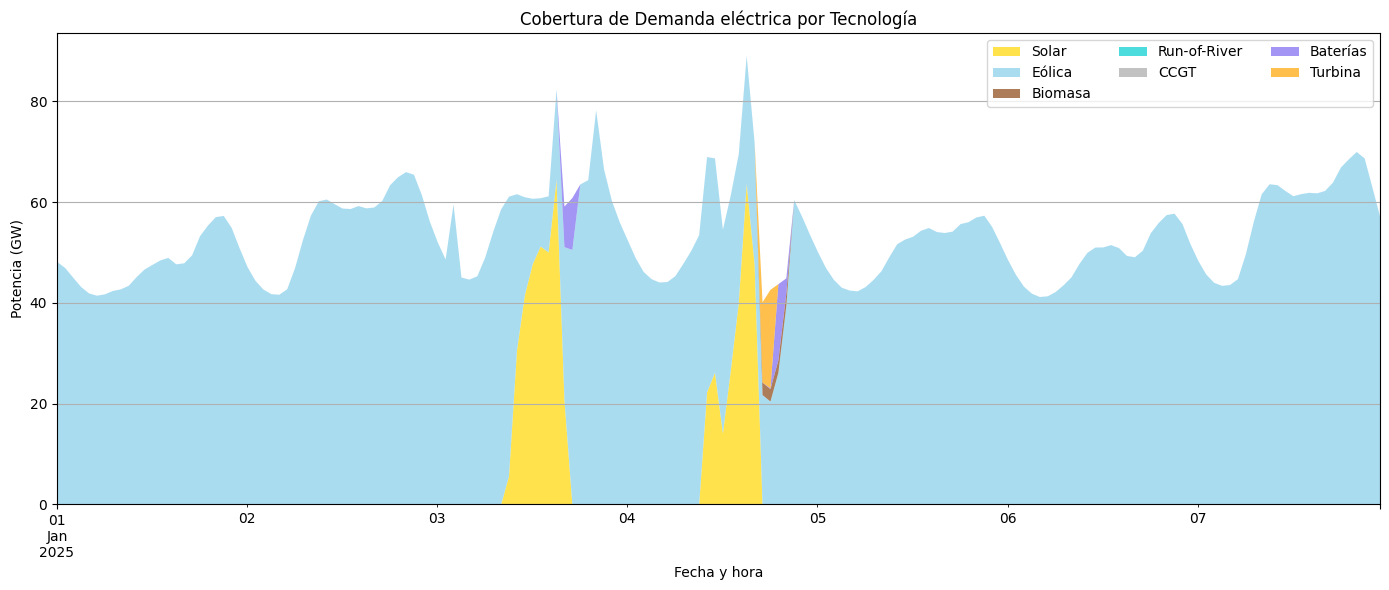

In [125]:
# 2) Index temporal
times = network.snapshots

# 3) Extrae generación de cada generator y asocia carriers
gen = network.generators_t.p                      # DataFrame (t × generators)
gen_car = network.generators["carrier"]           # Series generator → carrier

# 4) Construye series por carrier renovable
renew_carriers = ["Solar", "Wind", "Biomass", "Water", "Gas"]
renew_series = {
    car: gen.loc[:, gen_car == car].sum(axis=1)
    for car in renew_carriers
}

# 5) Extrae CCGT, Turbina y Baterías
ccgt   = -network.links_t.p1["CCGT"].clip(upper=0)
turb   = -network.links_t.p1["Turbina"].clip(upper=0)

# (o, si prefieres basarte en el nombre)
battery_sus = [n for n in network.storage_units.index if "battery" in n.lower()]
h2_sus      = [n for n in network.storage_units.index if "hstor"  in n.lower()]

# 7) Suma neta (descarga +, carga –)
bat_net = network.storage_units_t.p[battery_sus].sum(axis=1)
h2_net  = network.storage_units_t.p[h2_sus].sum(axis=1)

# 8) Descargas (oferta) 
battery_discharge = bat_net.clip(lower=0)
h2_discharge      = h2_net.clip(lower=0)

# 6) Monta el DataFrame final (en MW o GW dividiendo entre 1e3)
df_plot = pd.DataFrame({
    "Solar":         renew_series["Solar"]     / 1e3,
    "Eólica":        renew_series["Wind"]      / 1e3,
    "Biomasa":       renew_series["Biomass"]   / 1e3,
    "Run-of-River":  renew_series["Water"]/1e3,
    "CCGT":          ccgt   / 1e3,
    "Baterías":      battery_discharge/ 1e3,
   #  "H2 Storage":            h2_discharge / 1e3,
    "Turbina":       turb   / 1e3,
}, index=times)
# 7) Colores (ajusta a tu gusto)
colors = {
    "Solar":        "#FFD700",
    "Eólica":       "#87CEEB",
    "Biomasa":      "#8B4513",
    "Run-of-River": "#00CED1",
    "CCGT":         "#A9A9A9",
    "Baterías":     "#7B68EE",
    "Turbina":      "#FFA500",
   #  "H2 Storage":           "#32CD32",
}

c = [colors[col] for col in df_plot.columns]

# 8) Grafica área apilada
fig, ax = plt.subplots(figsize=(14, 6))
df_plot.plot(
    kind="area", ax=ax,
    color=c, alpha=0.7, linewidth=0
)
ax.set_title("Cobertura de Demanda eléctrica por Tecnología")
ax.set_xlabel("Fecha y hora")
ax.set_ylabel("Potencia (GW)")
ax.legend(loc="upper right", ncol=3)
ax.grid(True)
plt.tight_layout()
plt.show()

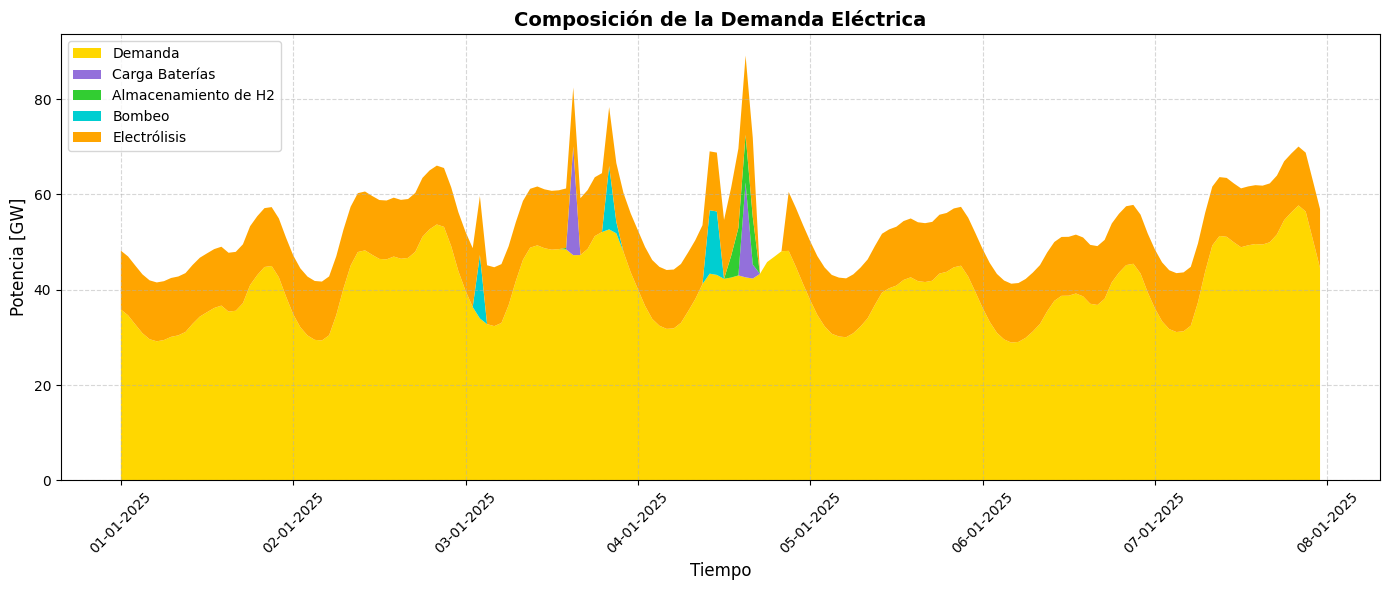

In [126]:
# --------------- Demanda nacional (MW → GW) -----------------------------------------------------------
national_demand = network.loads_t.p_set["Demanda_Nacional"]/ 1e3
# --------------- Carga de baterías (solo valores de carga → negativos en storage.p) -------------------
battery_sus = [n for n in network.storage_units.index if "battery" in n.lower()]
h2_sus      = [n for n in network.storage_units.index if "hstor"  in n.lower()]
battery_charge = (network.storage_units_t.p[battery_sus]
                  .clip(upper=0)
                  .sum(axis=1)
                  .abs() / 1e3)
h2_charge= (network.storage_units_t.p[h2_sus]
                  .clip(upper=0)
                  .sum(axis=1)
                  .abs() / 1e3)
# -------------- Bombeo hidráulico (extracción de electricity → links_t.p0 positivo) -------------------
pumped_links = [l for l in network.links.index 
                if "pump" in l.lower() or "bombeo" in l.lower()]
pumping_demand = (network.links_t.p0[pumped_links]
                  .clip(lower=0)
                  .sum(axis=1) / 1e3)
# -------------- Electrolysis (idem bombeo: consumo eléctrico en p0) ------------------------------------
electrolyzer_links = [l for l in network.links.index 
                      if "electrolyzer" in l.lower()]
electrolyzer_demand = (network.links_t.p0[electrolyzer_links]
                       .clip(lower=0)
                       .sum(axis=1) / 1e3)
electrolyzer_demand_final=electrolyzer_demand- h2_charge
# ------------------ Gráfica ----------------------------------------------------------------------------
plt.figure(figsize=(14, 6))
plt.stackplot(
    national_demand.index,
    national_demand,
    battery_charge,
    h2_charge,
    pumping_demand,
    electrolyzer_demand_final,
   labels=["Demanda", "Carga Baterías","Almacenamiento de H2", "Bombeo", "Electrólisis"],
   colors=[
        "#FFD700",  # Demanda (amarillo)
        "#9370DB",  # Carga Baterías (púrpura)
        "#32CD32",  # Carga H₂ (verde)  
        "#00CED1",  # Bombeo (cian)
        "#FFA500",  # Electrólisis (naranja)
   ],
    linewidth=0.5
)
plt.title("Composición de la Demanda Eléctrica", fontsize=14, fontweight="bold")
plt.xlabel("Tiempo", fontsize=12)
plt.ylabel("Potencia [GW]", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=10)
plt.tight_layout()
# ---------------- Formato del eje X ---------------------------------------------------------------------
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y'))
plt.show()


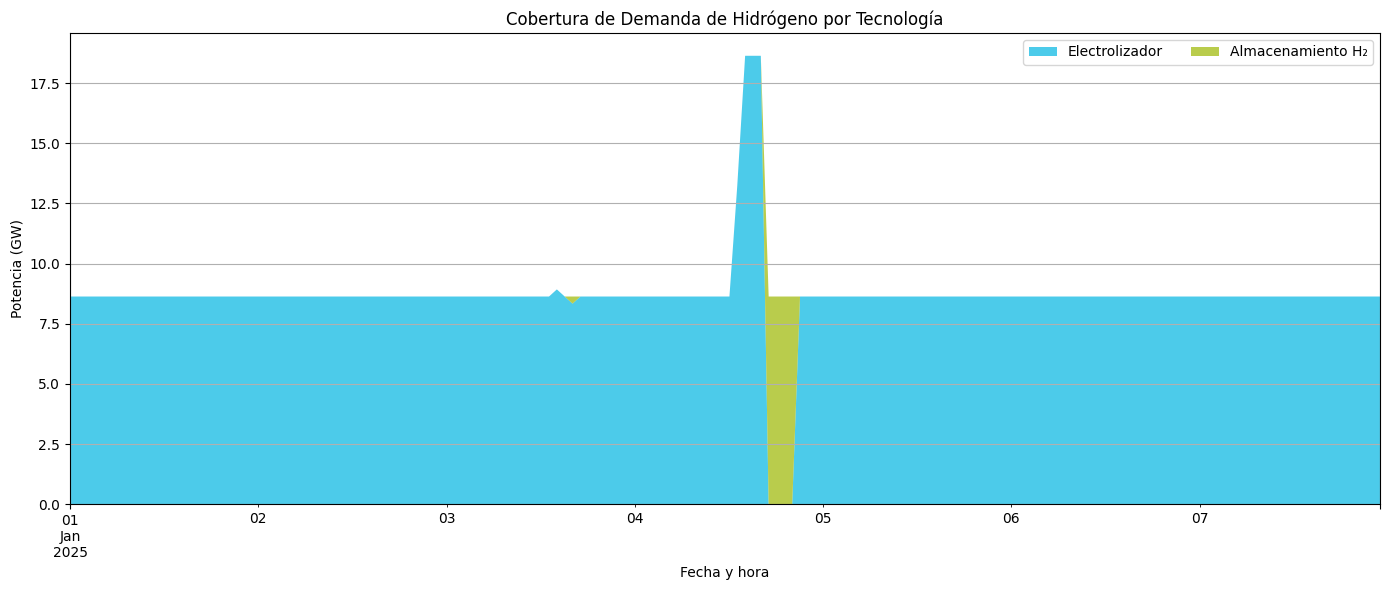

In [127]:
# ------------------ Índice temporal ---------------------------------------------------------
times = network.snapshots
# ------------------ Electrolizador ----------------------------------------------------------
# Potencia eléctrica consumida para producir H₂ (en MW)
electrolyzer = -network.links_t.p1["Electrolyzer"].clip(upper=0)
# ------------------ Almacenamiento H₂ -------------------------------------------------------
# Identifica unidades de almacenamiento de H₂
h2_sus = [n for n in network.storage_units.index if "hstor" in n.lower()]
# Potencia neta (descarga positiva) ----------------------------------------------------------
h2_net = network.storage_units_t.p[h2_sus].sum(axis=1)
h2_discharge = h2_net.clip(lower=0)
# ------------------ DataFrame para la gráfica -----------------------------------------------
df_plot = pd.DataFrame({
    "Electrolizador": electrolyzer / 1e3,        # GW
    "Almacenamiento H₂": h2_discharge / 1e3,     # GW
}, index=times)
# ------------------ Colores -----------------------------------------------------------------
colors = {
    "Electrolizador": "#00B5E2",
    "Almacenamiento H₂": "#9CB700",
}
c = [colors[col] for col in df_plot.columns]
# ------------------ Gráfica -----------------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 6))
df_plot.plot(kind="area", ax=ax, color=c, alpha=0.7, linewidth=0)
ax.set_title("Cobertura de Demanda de Hidrógeno por Tecnología")
ax.set_xlabel("Fecha y hora")
ax.set_ylabel("Potencia (GW)")
ax.legend(loc="upper right", ncol=2)
ax.grid(True)
plt.tight_layout()
plt.show()

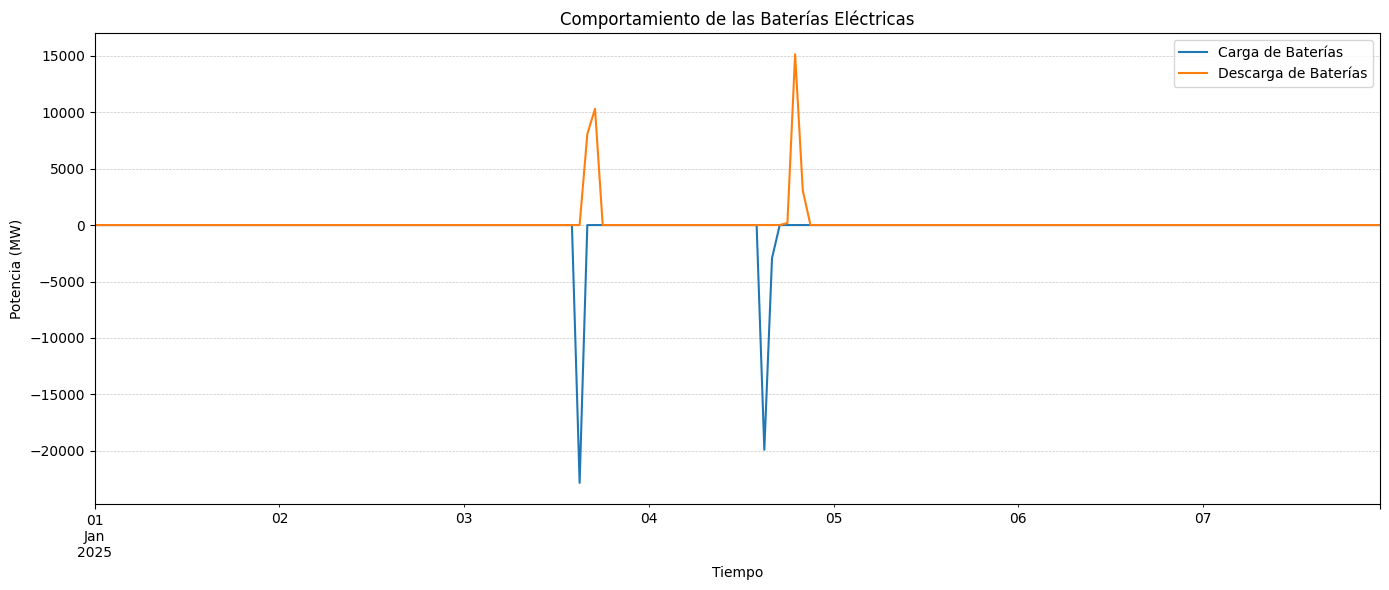

In [128]:
#Grafica de la baterias electricas

#extraemos la serie de carga de las baterias electricas
battery_charge = network.storage_units_t.p["Battery"].clip(upper=0)
#extraemos la serie de descarga de las baterias electricas
battery_discharge = network.storage_units_t.p["Battery"].clip(lower=0)
#graficamos la carga y descarga de las baterias electricas
plt.figure(figsize=(14, 6))
battery_charge.plot(label="Carga de Baterías", color="tab:blue")
battery_discharge.plot(label="Descarga de Baterías", color="tab:orange")
plt.title("Comportamiento de las Baterías Eléctricas")
plt.ylabel("Potencia (MW)")
plt.xlabel("Tiempo")
plt.legend()
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)
plt.tight_layout()
plt.show()

# OJO

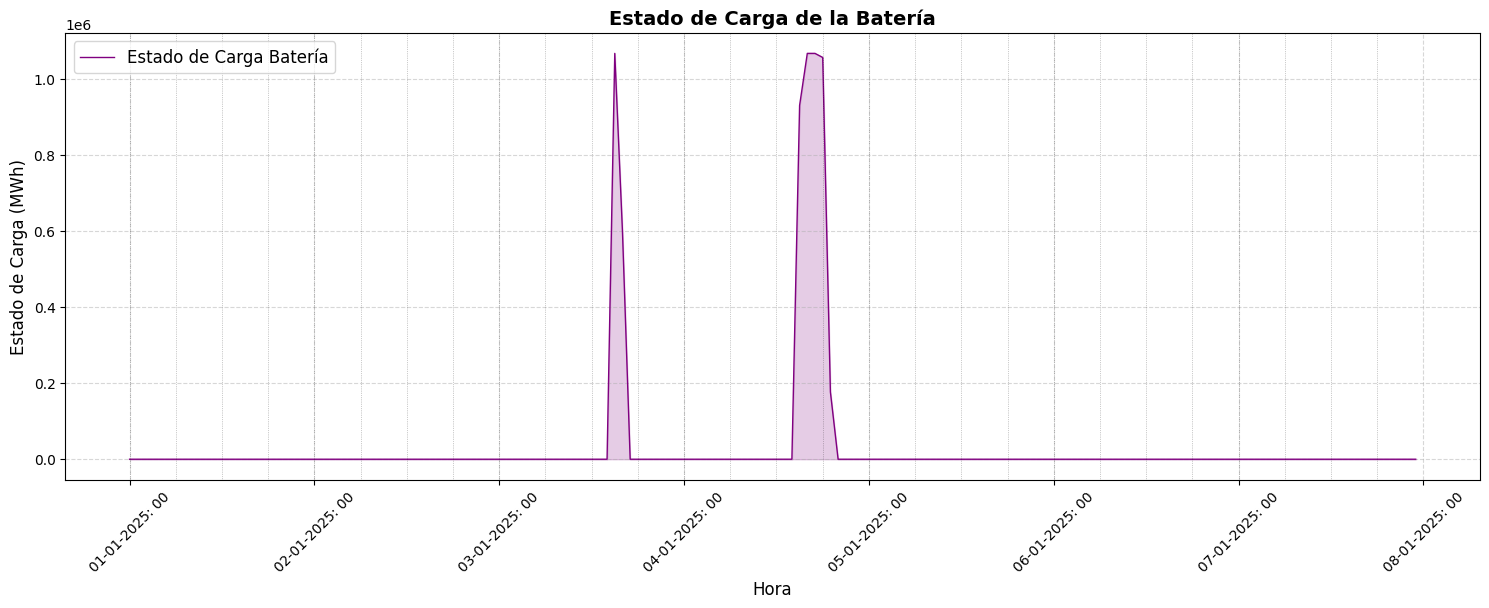

In [129]:
#Grafica del estado de carga de las baterías
soc_batt = network.storage_units_t.state_of_charge["Battery"]
plt.figure(figsize=(15, 6))
plt.style.use('default')
plt.plot(hours, soc_batt, label="Estado de Carga Batería", color="purple", linewidth=1, linestyle="-")
plt.fill_between(hours, soc_batt, color="purple", alpha=0.2)    
plt.title("Estado de Carga de la Batería", fontsize=14, fontweight="bold")
plt.xlabel("Hora", fontsize=12)
plt.ylabel("Estado de Carga (MWh)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=12)
plt.tight_layout()
for day in pd.date_range("2025-01-01", "2025-01-07"):
    for hour in [0, 6, 12, 18]:
        timestamp = pd.Timestamp(day.date()) + pd.Timedelta(hours=hour)
        plt.axvline(x=timestamp, color='black', linestyle=':', linewidth=0.5, alpha=0.4)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y: %H'))
plt.xticks(rotation=45)
plt.show()